In [15]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Multilingual Finetuning

In [38]:
cer_results_multi = {
    "HL-houlsby-v01": 29.3,
    "HL-lora-v01": 31.3,
    "HL-frozen-v01": 31.1,  # 12 language set
    "HL-frozen-v02": 30.5,  # smaller subset of languages
    "XLSR-frozen-v01": 28.9,  # 12 language set
}
mean_multi_cer = np.mean(list(cer_results_multi.values()))
mean_multi_cer

np.float64(30.22)

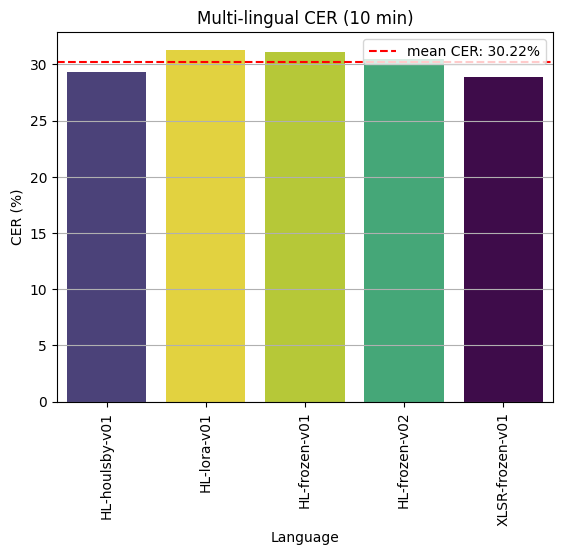

In [39]:
sns.barplot(x=list(cer_results_multi.keys()), y=list(cer_results_multi.values()),
            palette='viridis', hue=list(cer_results_multi.values()), legend=False)
plt.title("Multi-lingual CER (10 min)")
plt.axhline(mean_multi_cer, color='red', linestyle='--', label=f'mean CER: {mean_multi_cer:.2f}%')
plt.xlabel("Language")
plt.ylabel("CER (%)")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y')

- Results are suprisingly good for Hubert Large, considering the baseline:

![ml_superb](imgs/ml_superb_results.png)

Likely this is due to the choice of languages: 12 languages with latin script.

# Monolingual Finetuning

In [36]:
# 10 min
cer_results_mono = {
    "yor": 66.0,
    "wol": 55.6,
    "umb": 79.2,
    "umb": 79.2,
    "swa": 54.6,
    "sna": 62.2,
    "orm": 66.0,
    "luo": 64.9,
    "lug": 71.1,
    "lin": 68.8,
    "kin": 77.8,
    # "hau": 0.9,  # commonvoice contamination
    "ibo": 69.6,
}
mean_mono_cer = np.mean(list(cer_results_mono.values()))
mean_mono_cer

np.float64(66.89090909090909)

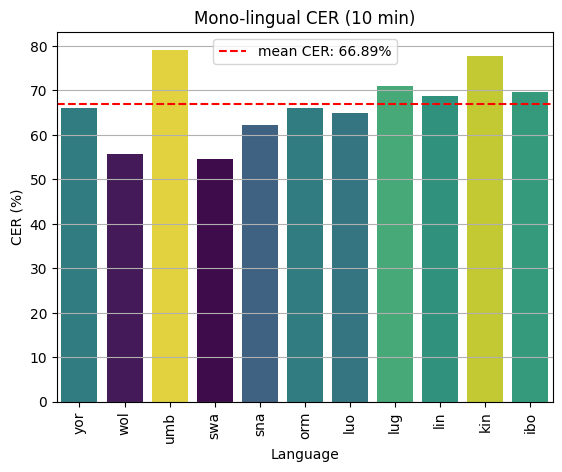

In [37]:
sns.barplot(x=list(cer_results_mono.keys()), y=list(cer_results_mono.values()),
            palette='viridis', hue=list(cer_results_mono.values()), legend=False)
plt.title("Mono-lingual CER (10 min)")
plt.axhline(mean_mono_cer, color='red', linestyle='--', label=f'mean CER: {mean_mono_cer:.2f}%')
plt.xlabel("Language")
plt.ylabel("CER (%)")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y')

### Comments



- Monolingual training is not very successful, it overfits immeadeatly as validation curves grow.

Swahili training curve:

![train_swa](imgs/loss_ctc_swa.png)

There is likely a need to reduce the number of steps per epoch

- Compare against multilingual with a proper training case.

# Tasks to follow

- improve monolingual baseline:
    - what is happenning before epoch 1?
    - btw, i am curious what happens with epoch 1 in multilingual as well
- rethink choice of datasets: maybe something more elaborate than just the latin script
- redo with xlsr-128
- domain shift to MST